# 30-Day Readmission Prediction: Random Forest
**Author:** Om Prajapati  
**Project:** DS4400 — 30 Day Readmission Prediction in Diabetic Patients  
**Dataset:** Diabetes 130-US Hospitals 1999-2008

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
import os

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
)

import warnings
warnings.filterwarnings('ignore')

print('imports done')

imports done


## Load Preprocessed Data

In [2]:
# figure out root whether we run from repo root or notebooks/
_cwd = Path(os.getcwd())
ROOT = _cwd if (_cwd / 'data').exists() else _cwd.parent

PROCESSED_DIR = ROOT / 'data' / 'processed'
RESULTS_DIR   = ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

X_train_sc    = joblib.load(PROCESSED_DIR / 'X_train_sc.pkl')
X_test_sc     = joblib.load(PROCESSED_DIR / 'X_test_sc.pkl')
y_train_bal   = joblib.load(PROCESSED_DIR / 'y_train_bal.pkl')
y_test        = joblib.load(PROCESSED_DIR / 'y_test.pkl')
feature_names = joblib.load(PROCESSED_DIR / 'feature_names.pkl')
SMOTE_AVAILABLE = joblib.load(PROCESSED_DIR / 'smote_available.pkl')

print(f'Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}')
print(f'Train positive rate: {y_train_bal.mean():.3f}')
print(f'Test positive rate:  {y_test.mean():.3f}')
print(f'SMOTE applied: {SMOTE_AVAILABLE}')

Train: (76538, 44)  |  Test: (19135, 44)
Train positive rate: 0.115
Test positive rate:  0.115
SMOTE applied: False


## Baseline Random Forest

In [3]:
# if SMOTE already balanced the training data we don't also want class_weight='balanced'
# — that would double-correct for imbalance. since SMOTE wasn't applied here we use balanced weights.
class_weight_setting = None if SMOTE_AVAILABLE else 'balanced'

# baseline model with default hyperparams, we'll tune these below
rf_base = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weight_setting,
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train_sc, y_train_bal)
print('baseline RF trained')

baseline RF trained



Random Forest (Baseline)
  Accuracy  : 0.8846
  Precision : 0.4595
  Recall    : 0.0077
  F1 Score  : 0.0152
  ROC-AUC   : 0.6308

              precision    recall  f1-score   support

    Not <30d       0.89      1.00      0.94     16930
Readmit <30d       0.46      0.01      0.02      2205

    accuracy                           0.88     19135
   macro avg       0.67      0.50      0.48     19135
weighted avg       0.84      0.88      0.83     19135



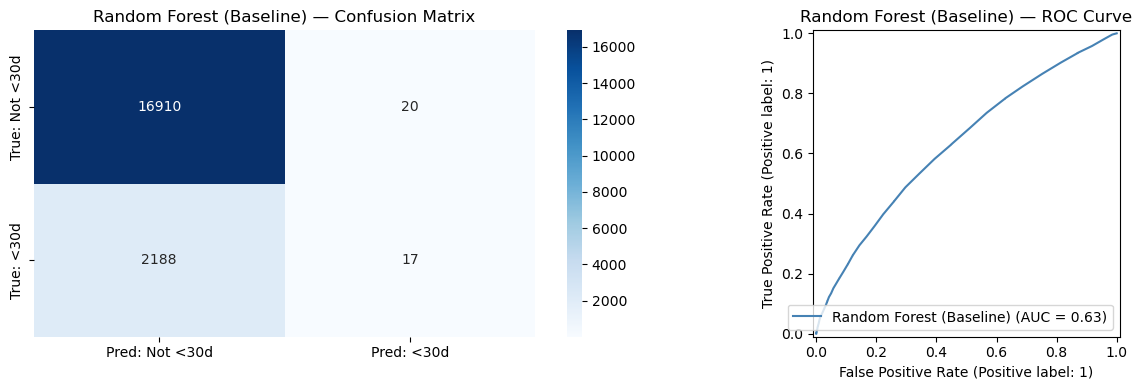

In [4]:
def evaluate_model(model, X_test, y_test, model_name='Model'):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    roc  = roc_auc_score(y_test, y_prob)
    cm   = confusion_matrix(y_test, y_pred)

    print(f'\n{model_name}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  ROC-AUC   : {roc:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=['Not <30d', 'Readmit <30d']))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred: Not <30d', 'Pred: <30d'],
                yticklabels=['True: Not <30d', 'True: <30d'], ax=axes[0])
    axes[0].set_title(f'{model_name} — Confusion Matrix')

    RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                     name=model_name, color='steelblue')
    axes[1].set_title(f'{model_name} — ROC Curve')

    plt.tight_layout()
    fname = RESULTS_DIR / (model_name.lower().replace(' ', '_') + '_eval.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec, 'roc_auc': roc}


baseline_metrics = evaluate_model(rf_base, X_test_sc, y_test, 'Random Forest (Baseline)')

## Hyperparameter Tuning (GridSearchCV)

In [5]:
# tuning the most impactful RF params:
# - n_estimators: more trees = more stable, but diminishing returns past ~200
# - max_depth: None means fully grown trees (can overfit), limiting depth controls that
# - min_samples_split: how many samples a node needs before it's allowed to split
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 10],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# n_jobs=1 in GridSearchCV so only one model trains at a time —
# each RF still uses all cores internally via n_jobs=-1 on the estimator.
# running grid search jobs in parallel would spawn N×N processes and run out of RAM.
grid_search = GridSearchCV(
    RandomForestClassifier(class_weight=class_weight_setting, random_state=42, n_jobs=-1),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=1,
    verbose=1
)

# this will take a while since we're training 12 RF models with 5-fold CV each (60 total fits) — but it's not too bad since RFs are pretty fast to train and we're only using 100-200 trees.
grid_search.fit(X_train_sc, y_train_bal)

print(f'\nBest params: {grid_search.best_params_}')
print(f'Best CV F1:  {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1:  0.2682



Random Forest (Tuned)
  Accuracy  : 0.6755
  Precision : 0.1823
  Recall    : 0.5211
  F1 Score  : 0.2701
  ROC-AUC   : 0.6570

              precision    recall  f1-score   support

    Not <30d       0.92      0.70      0.79     16930
Readmit <30d       0.18      0.52      0.27      2205

    accuracy                           0.68     19135
   macro avg       0.55      0.61      0.53     19135
weighted avg       0.83      0.68      0.73     19135



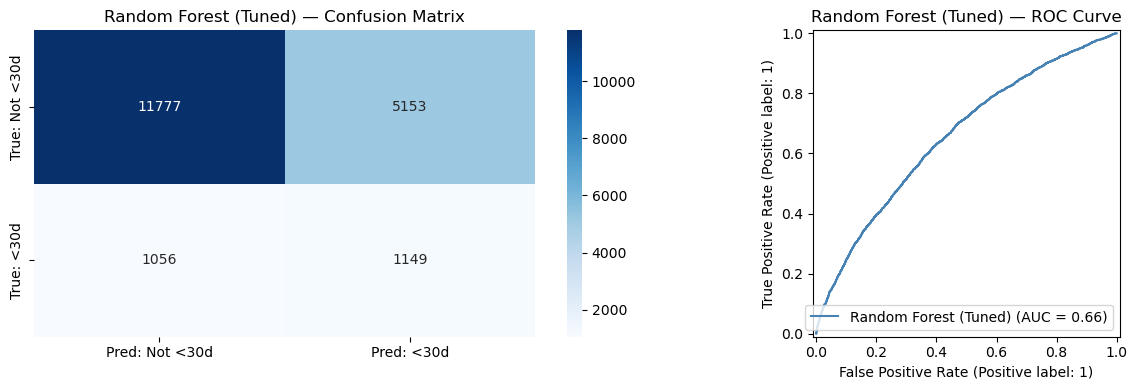

In [6]:
best_rf = grid_search.best_estimator_
tuned_metrics = evaluate_model(best_rf, X_test_sc, y_test, 'Random Forest (Tuned)')

## Cross-Validation on Tuned Model

5-Fold CV F1 scores: [0.27265872 0.2631977  0.27175898 0.26816339 0.26516517]
Mean: 0.2682 ± 0.0037


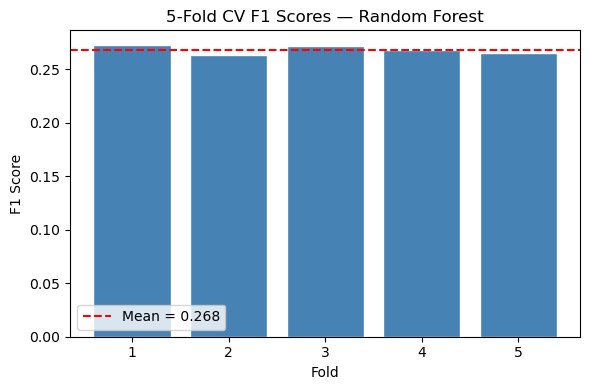

In [7]:
# same deal — n_jobs=1 here so we're not spawning parallel RF processes
cv_scores = cross_val_score(best_rf, X_train_sc, y_train_bal, cv=cv, scoring='f1', n_jobs=1)

print(f'5-Fold CV F1 scores: {cv_scores}')
print(f'Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

plt.figure(figsize=(6, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='white')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.title('5-Fold CV F1 Scores — Random Forest')
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'rf_cv_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## Feature Importance

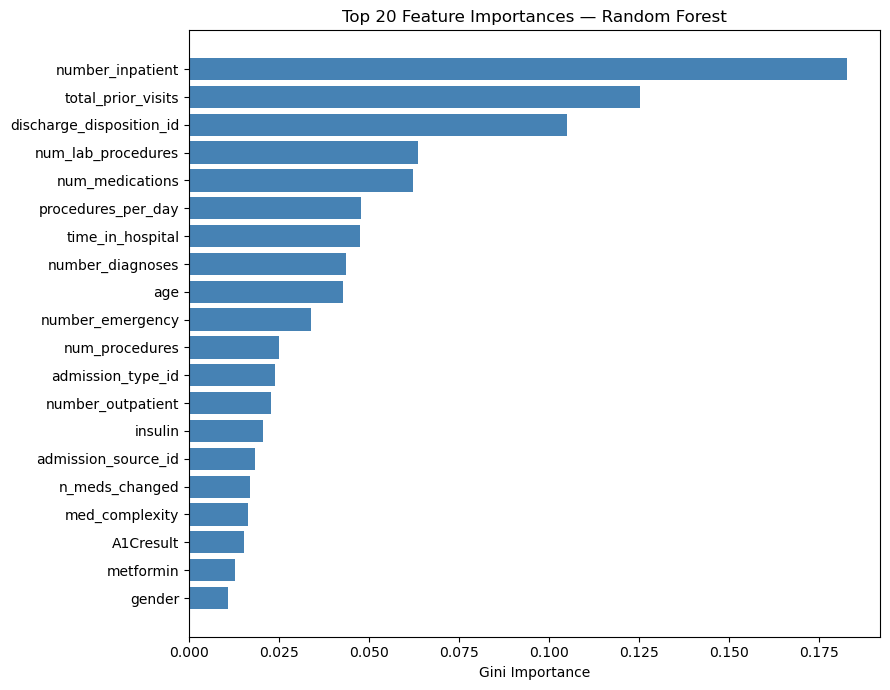


Top 20 features:
                 feature  importance
        number_inpatient    0.182890
      total_prior_visits    0.125355
discharge_disposition_id    0.105074
      num_lab_procedures    0.063732
         num_medications    0.062148
      procedures_per_day    0.047802
        time_in_hospital    0.047477
        number_diagnoses    0.043680
                     age    0.042882
        number_emergency    0.033773
          num_procedures    0.025095
       admission_type_id    0.023767
       number_outpatient    0.022859
                 insulin    0.020451
     admission_source_id    0.018452
          n_meds_changed    0.017050
          med_complexity    0.016376
               A1Cresult    0.015296
               metformin    0.012717
                  gender    0.010878


In [8]:
# random forest gives us Gini importance for each feature —
# basically how much each feature reduces impurity across all trees on average
importances = best_rf.feature_importances_

feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False)

top_n = 20
top_feats = feat_df.head(top_n)

plt.figure(figsize=(9, 7))
plt.barh(top_feats['feature'][::-1], top_feats['importance'][::-1], color='steelblue')
plt.xlabel('Gini Importance')
plt.title(f'Top {top_n} Feature Importances — Random Forest')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 20 features:')
print(feat_df[['feature', 'importance']].head(20).to_string(index=False))

## Summary

             accuracy      f1  precision  recall  roc_auc
Model                                                    
RF Baseline    0.8846  0.0152     0.4595  0.0077   0.6308
RF Tuned       0.6755  0.2701     0.1823  0.5211   0.6570


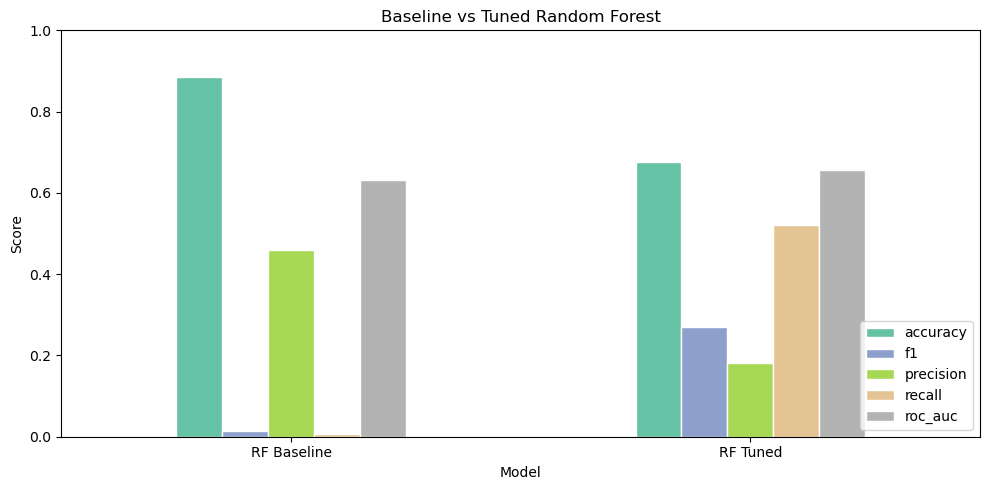

In [9]:
summary = pd.DataFrame([
    {'Model': 'RF Baseline', **baseline_metrics},
    {'Model': 'RF Tuned',    **tuned_metrics},
]).set_index('Model').round(4)

print(summary.to_string())

summary.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('Baseline vs Tuned Random Forest')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'rf_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()